# Universidad del Valle de Guatemala
## Departamento de Ciencias de la Computación
## Inteligencia Artificial - sección 10

# Proyecto No. 2

### Nadissa Vela - 23764
### Cristian Túnchez - 231359

--------



# Task 1 — Configuración Segura de la Red
## CSP y Factor Graphs aplicados a Ciberseguridad
  
Asignación de protocolos de seguridad a servidores en una red distribuida,  
garantizando que ningún par de servidores conectados comparta el mismo protocolo (movimiento lateral).

---

## 1. Modelado Formal como CSP con Factor Graphs

### Definición del Problema

Dado un grafo $G = (V, E)$ que representa la red de servidores:

| Componente CSP | Definición en el Problema |
|---|---|
| **Variables** | $X = \{X_1, X_2, \ldots, X_n\}$ — un servidor por variable |
| **Dominios** | $\text{Dom}_i = \{\text{Rojo}, \text{Verde}, \text{Azul}, \text{Amarillo}\}$ para todo $i$ |
| **Factores** | $f_{ij}(X_i, X_j) = [X_i \neq X_j]$ para cada arista $(i,j) \in E$ |

### Factor Graph

$$\text{Weight}(x) = \prod_{(i,j) \in E} f_{ij}(x_i, x_j)$$

- Cada factor $f_{ij}$ es una **restricción binaria** que devuelve 1 si $x_i \neq x_j$, y 0 si son iguales.
- Una asignación es **consistente** iff $\text{Weight}(x) = 1$ (todas las restricciones satisfechas).
- **Objetivo:** $\arg\max_x \text{Weight}(x)$ — encontrar cualquier asignación con peso máximo 1.

### Restricción de Seguridad

$$\forall (i, j) \in E: \quad \text{protocolo}(i) \neq \text{protocolo}(j)$$

Esto evita vulnerabilidades de **movimiento lateral**: si un servidor es comprometido, el protocolo diferente en servidores vecinos limita la propagación del ataque.

---
## 2. Imports y Generación del Grafo

In [2]:
import random
import time
import copy
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import defaultdict

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Protocolos de seguridad (representados como colores)
PROTOCOLS = ["Rojo", "Verde", "Azul", "Amarillo"]
PROTOCOL_COLORS = {
    "Rojo":     "#e74c3c",
    "Verde":    "#2ecc71",
    "Azul":     "#3498db",
    "Amarillo": "#f1c40f",
    None:       "#bdc3c7"   # sin asignar
}

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [3]:
def generate_network(n_nodes: int = 17, edge_prob: float = 0.35, seed: int = SEED) -> nx.Graph:
    """
    Genera un grafo aleatorio conectado que representa la red de servidores.
    Usa el modelo Erdős–Rényi y garantiza conectividad.
    """
    rng = random.Random(seed)
    
    while True:
        G = nx.erdos_renyi_graph(n_nodes, edge_prob, seed=seed)
        if nx.is_connected(G):
            # Renombrar nodos como "S0", "S1", ...
            mapping = {i: f"S{i}" for i in range(n_nodes)}
            G = nx.relabel_nodes(G, mapping)
            return G
        seed += 1  # probar otra semilla si no está conectado


# Generar red con 17 servidores
G = generate_network(n_nodes=17, edge_prob=0.35)

print(f"Red generada:")
print(f"  Servidores (nodos): {G.number_of_nodes()}")
print(f"  Conexiones (aristas): {G.number_of_edges()}")
print(f"  Grado promedio: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
print(f"  Es conectado: {nx.is_connected(G)}")
print(f"\nServidores: {list(G.nodes())}")

Red generada:
  Servidores (nodos): 17
  Conexiones (aristas): 53
  Grado promedio: 6.24
  Es conectado: True

Servidores: ['S0', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16']


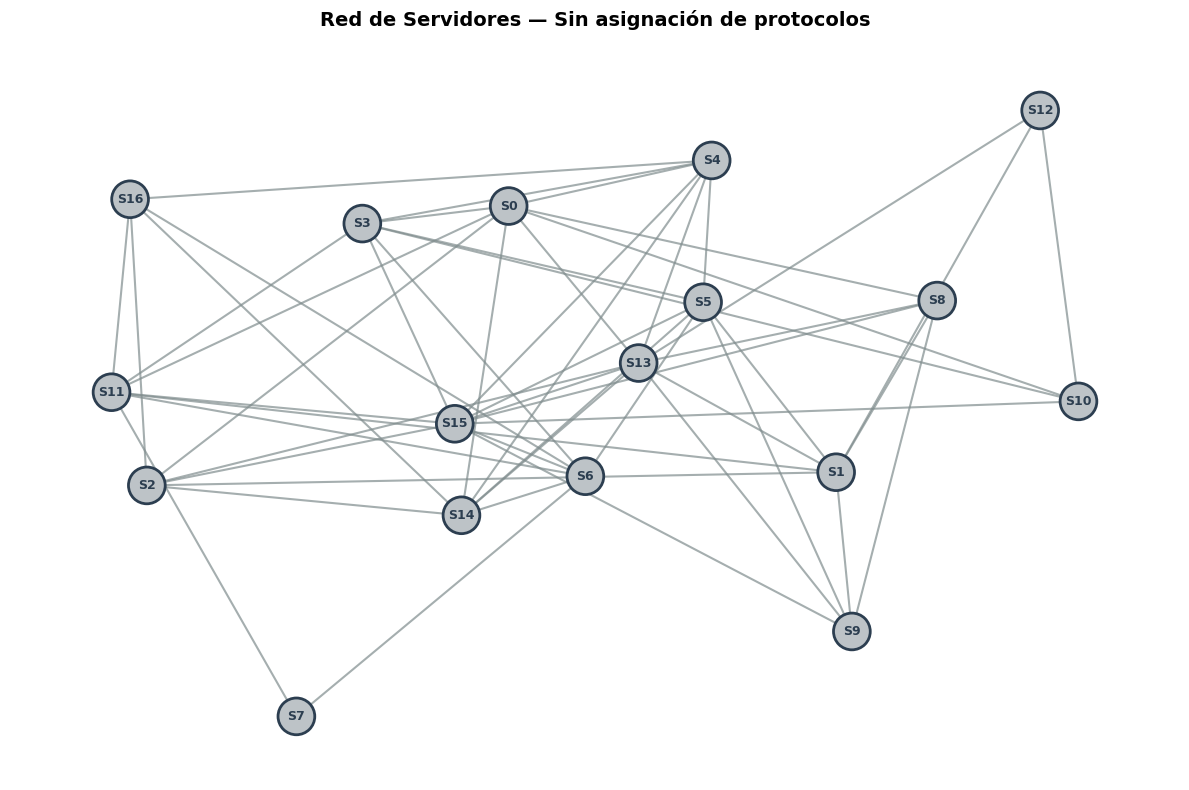

In [4]:
def plot_network(G: nx.Graph, assignment: dict = None, title: str = "Red de Servidores"):
    """
    Visualiza la red de servidores. Si hay asignación, colorea los nodos
    con el protocolo asignado.
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=SEED, k=1.5)
    
    node_colors = []
    for node in G.nodes():
        protocol = assignment.get(node) if assignment else None
        node_colors.append(PROTOCOL_COLORS[protocol])
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700,
                           edgecolors="#2c3e50", linewidths=2, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="#7f8c8d", width=1.5,
                           alpha=0.7, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold",
                            font_color="#2c3e50", ax=ax)
    
    # Leyenda de protocolos
    if assignment:
        patches = [mpatches.Patch(color=PROTOCOL_COLORS[p], label=f"Protocolo {p}")
                   for p in PROTOCOLS]
        patches.append(mpatches.Patch(color=PROTOCOL_COLORS[None], label="Sin asignar"))
        ax.legend(handles=patches, loc="upper left", fontsize=10)
    
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_network(G, title="Red de Servidores — Sin asignación de protocolos")

---
## 3. Implementación del CSP

In [5]:
class NetworkSecurityCSP:
    """
    Modela el problema de asignación de protocolos de seguridad
    como un Problema de Satisfacción de Restricciones (CSP).

    Factor Graph:
      - Variables: servidores de la red
      - Dominio_i: {Rojo, Verde, Azul, Amarillo}
      - Factor f_ij(Xi, Xj) = [Xi != Xj] para cada arista (i,j)
    """

    def __init__(self, graph: nx.Graph, protocols: list):
        self.graph     = graph
        self.variables = list(graph.nodes())
        self.protocols = protocols
        # Dominio inicial: todos los protocolos disponibles para cada servidor
        self.domains   = {v: list(protocols) for v in self.variables}
        # Vecinos: servidores conectados directamente
        self.neighbors = {v: list(graph.neighbors(v)) for v in self.variables}

    # ------------------------------------------------------------------
    # Factor Graph
    # ------------------------------------------------------------------

    def factor(self, xi: str, xj: str, val_i, val_j) -> int:
        """
        f_ij(xi, xj) = 1 si val_i != val_j (restricción satisfecha), 0 si son iguales.
        Solo se evalúa si existe arista entre xi y xj.
        """
        if self.graph.has_edge(xi, xj):
            return int(val_i != val_j)
        return 1  # sin arista → no hay restricción → factor neutro

    def weight(self, assignment: dict) -> int:
        """
        Weight(x) = producto de todos los factores sobre aristas asignadas.
        Una asignación completa es consistente iff Weight(x) = 1.
        """
        w = 1
        checked = set()
        for node, val in assignment.items():
            for neighbor in self.neighbors[node]:
                if neighbor in assignment:
                    edge = tuple(sorted((node, neighbor)))
                    if edge not in checked:
                        w *= self.factor(node, neighbor, val, assignment[neighbor])
                        checked.add(edge)
                        if w == 0:
                            return 0
        return w

    def delta(self, assignment: dict, xi: str, val) -> int:
        """
        δ = producto de los factores dependientes de Xi dado la asignación parcial actual.
        Evalúa solo los factores donde xi y su vecino ya están asignados.
        """
        d = 1
        for neighbor in self.neighbors[xi]:
            if neighbor in assignment:
                d *= self.factor(xi, neighbor, val, assignment[neighbor])
                if d == 0:
                    return 0
        return d

    def is_consistent(self, assignment: dict) -> bool:
        """Verifica si la asignación (parcial o completa) es consistente."""
        return self.weight(assignment) == 1

    def __repr__(self):
        return (f"NetworkSecurityCSP("
                f"variables={len(self.variables)}, "
                f"protocols={self.protocols}, "
                f"constraints={self.graph.number_of_edges()})")


csp = NetworkSecurityCSP(G, PROTOCOLS)
print(csp)
print(f"\nEjemplo de vecinos de S0: {csp.neighbors['S0']}")
print(f"Dominio de S0: {csp.domains['S0']}")

NetworkSecurityCSP(variables=17, protocols=['Rojo', 'Verde', 'Azul', 'Amarillo'], constraints=53)

Ejemplo de vecinos de S0: ['S2', 'S3', 'S4', 'S8', 'S10', 'S11', 'S13', 'S14']
Dominio de S0: ['Rojo', 'Verde', 'Azul', 'Amarillo']


---
## 4. Backtracking Puro (sin heurísticas)

In [6]:
class BacktrackingPure:
    """
    Backtracking Search básico.
    - Selección de variable: orden fijo (lista de variables tal como están).
    - Orden de valores: orden fijo del dominio.
    - Sin lookahead ni propagación de restricciones.
    """

    def __init__(self, csp: NetworkSecurityCSP):
        self.csp             = csp
        self.calls           = 0   # nodos explorados en el árbol
        self.assignments_tried = 0 # asignaciones individuales intentadas

    def solve(self) -> dict | None:
        self.calls = 0
        self.assignments_tried = 0
        assignment = {}
        result = self._backtrack(assignment)
        return result

    def _backtrack(self, assignment: dict) -> dict | None:
        self.calls += 1

        # Caso base: asignación completa
        if len(assignment) == len(self.csp.variables):
            return assignment

        # Seleccionar siguiente variable (orden fijo)
        xi = self._select_variable(assignment)

        # Probar cada valor del dominio (orden fijo)
        for value in self.csp.protocols:
            self.assignments_tried += 1

            # δ: verificar consistencia con vecinos ya asignados
            delta = self.csp.delta(assignment, xi, value)
            if delta == 0:
                continue  # restricción violada → podar

            assignment[xi] = value
            result = self._backtrack(assignment)
            if result is not None:
                return result
            del assignment[xi]

        return None  # backtrack

    def _select_variable(self, assignment: dict) -> str:
        """Orden fijo: primera variable no asignada en la lista original."""
        for var in self.csp.variables:
            if var not in assignment:
                return var


print("BacktrackingPure definido.")

BacktrackingPure definido.


---
## 5. Backtracking Optimizado (MCV + Lookahead)

In [7]:
class BacktrackingOptimized:
    """
    Backtracking Search con:
      - MCV (Minimum Remaining Values): elige la variable con menor dominio restante.
      - Lookahead / Forward Checking: tras asignar Xi, elimina valores inconsistentes
        de los dominios de sus vecinos.
      - LCV (Least Constraining Value): ordena valores del dominio dejando más
        opciones a los vecinos.
    """

    def __init__(self, csp: NetworkSecurityCSP):
        self.csp               = csp
        self.calls             = 0
        self.assignments_tried = 0

    def solve(self) -> dict | None:
        self.calls = 0
        self.assignments_tried = 0
        # Trabajamos con una copia de los dominios para no mutar el CSP original
        domains = {v: list(vals) for v, vals in self.csp.domains.items()}
        assignment = {}
        result = self._backtrack(assignment, domains)
        return result

    def _backtrack(self, assignment: dict, domains: dict) -> dict | None:
        self.calls += 1

        # Caso base: asignación completa
        if len(assignment) == len(self.csp.variables):
            return assignment

        # ── MCV: seleccionar variable con menor dominio restante ──────────────
        xi = self._select_variable_mcv(assignment, domains)

        # ── LCV: ordenar valores de menos a más restrictivos ──────────────────
        ordered_values = self._order_values_lcv(xi, assignment, domains)

        for value in ordered_values:
            self.assignments_tried += 1

            # δ: verificar consistencia inmediata con vecinos asignados
            delta = self.csp.delta(assignment, xi, value)
            if delta == 0:
                continue

            assignment[xi] = value

            # ── Lookahead / Forward Checking ──────────────────────────────────
            domains_pruned, failed = self._forward_check(xi, value, assignment, domains)

            if not failed:
                result = self._backtrack(assignment, domains_pruned)
                if result is not None:
                    return result

            del assignment[xi]

        return None  # backtrack

    # ------------------------------------------------------------------
    # MCV — Minimum Remaining Values
    # ------------------------------------------------------------------

    def _select_variable_mcv(self, assignment: dict, domains: dict) -> str:
        """
        Elige la variable no asignada con el dominio más pequeño.
        En caso de empate, desempata por número de vecinos no asignados
        (variable más restringida en el grafo).
        """
        unassigned = [v for v in self.csp.variables if v not in assignment]
        return min(
            unassigned,
            key=lambda v: (
                len(domains[v]),
                -sum(1 for n in self.csp.neighbors[v] if n not in assignment)
            )
        )

    # ------------------------------------------------------------------
    # LCV — Least Constraining Value
    # ------------------------------------------------------------------

    def _order_values_lcv(self, xi: str, assignment: dict, domains: dict) -> list:
        """
        Ordena los valores del dominio de xi de menor a mayor impacto sobre
        los vecinos no asignados (valor menos restrictivo primero).
        """
        def count_conflicts(val):
            conflicts = 0
            for neighbor in self.csp.neighbors[xi]:
                if neighbor not in assignment:
                    if val in domains[neighbor]:
                        conflicts += 1
            return conflicts

        return sorted(domains[xi], key=count_conflicts)

    # ------------------------------------------------------------------
    # Lookahead — Forward Checking
    # ------------------------------------------------------------------

    def _forward_check(self, xi: str, value, assignment: dict,
                        domains: dict) -> tuple[dict, bool]:
        """
        Después de asignar xi = value:
          - Elimina 'value' del dominio de cada vecino no asignado.
          - Si algún dominio queda vacío, retorna (_, failed=True).
        Retorna una COPIA de los dominios podados para no mutar el estado.
        """
        new_domains = {v: list(vals) for v, vals in domains.items()}

        for neighbor in self.csp.neighbors[xi]:
            if neighbor not in assignment:
                if value in new_domains[neighbor]:
                    new_domains[neighbor].remove(value)
                if len(new_domains[neighbor]) == 0:
                    return new_domains, True  # dominio vacío → fallo temprano

        return new_domains, False


print("BacktrackingOptimized definido.")

BacktrackingOptimized definido.


---
## 6. Ejecución y Comparación

In [8]:
def run_solver(solver, name: str) -> dict:
    """Ejecuta el solver y mide métricas de rendimiento."""
    print(f"{'='*55}")
    print(f"  Ejecutando: {name}")
    print(f"{'='*55}")

    start = time.perf_counter()
    solution = solver.solve()
    elapsed = time.perf_counter() - start

    if solution:
        print(f"\nSolución encontrada")
        print(f"Tiempo          : {elapsed*1000:.4f} ms")
        print(f"Nodos explorados : {solver.calls}")
        print(f"Asignaciones int.: {solver.assignments_tried}")
        print(f"\n  Asignación de protocolos:")
        for server, protocol in sorted(solution.items(), key=lambda x: int(x[0][1:])):
            print(f"    {server:5s} → {protocol}")
    else:
        print("Sin solución")

    return {
        "name":       name,
        "solution":   solution,
        "time_ms":    elapsed * 1000,
        "nodes":      solver.calls,
        "assignments": solver.assignments_tried,
    }


# Instanciar solvers
solver_pure = BacktrackingPure(csp)
solver_opt  = BacktrackingOptimized(csp)

# Ejecutar ambos
results_pure = run_solver(solver_pure, "Backtracking Puro")
print()
results_opt  = run_solver(solver_opt,  "Backtracking Optimizado (MCV + Lookahead + LCV)")

  Ejecutando: Backtracking Puro

Solución encontrada
Tiempo          : 3.1282 ms
Nodos explorados : 780
Asignaciones int.: 3087

  Asignación de protocolos:
    S0    → Rojo
    S1    → Rojo
    S2    → Verde
    S3    → Azul
    S4    → Verde
    S5    → Amarillo
    S6    → Verde
    S7    → Rojo
    S8    → Verde
    S9    → Azul
    S10   → Verde
    S11   → Amarillo
    S12   → Azul
    S13   → Amarillo
    S14   → Azul
    S15   → Rojo
    S16   → Rojo

  Ejecutando: Backtracking Optimizado (MCV + Lookahead + LCV)

Solución encontrada
Tiempo          : 0.2571 ms
Nodos explorados : 18
Asignaciones int.: 17

  Asignación de protocolos:
    S0    → Rojo
    S1    → Rojo
    S2    → Azul
    S3    → Amarillo
    S4    → Azul
    S5    → Verde
    S6    → Azul
    S7    → Rojo
    S8    → Azul
    S9    → Amarillo
    S10   → Verde
    S11   → Verde
    S12   → Azul
    S13   → Verde
    S14   → Amarillo
    S15   → Rojo
    S16   → Rojo


---
## 7. Verificación de la Solución

In [9]:
def verify_solution(G: nx.Graph, assignment: dict) -> bool:
    """
    Verifica que ningún par de servidores conectados comparta protocolo.
    Evalúa Weight(x) = producto de todos los factores binarios.
    """
    print("Verificando restricciones de la solución:")
    violations = []
    for u, v in G.edges():
        if assignment.get(u) == assignment.get(v):
            violations.append((u, v, assignment.get(u)))

    if violations:
        print(f"{len(violations)} violación(es) encontrada(s):")
        for u, v, p in violations:
            print(f"     {u} ↔ {v}: ambos con '{p}'")
        return False
    else:
        print(f"Todas las {G.number_of_edges()} restricciones satisfechas.")
        print(f"Weight(x) = 1  →  Asignación consistente")
        return True


solution = results_opt["solution"]
print("─" * 50)
verify_solution(G, solution)

──────────────────────────────────────────────────
Verificando restricciones de la solución:
Todas las 53 restricciones satisfechas.
Weight(x) = 1  →  Asignación consistente


True

---
## 8. Visualización de la Solución

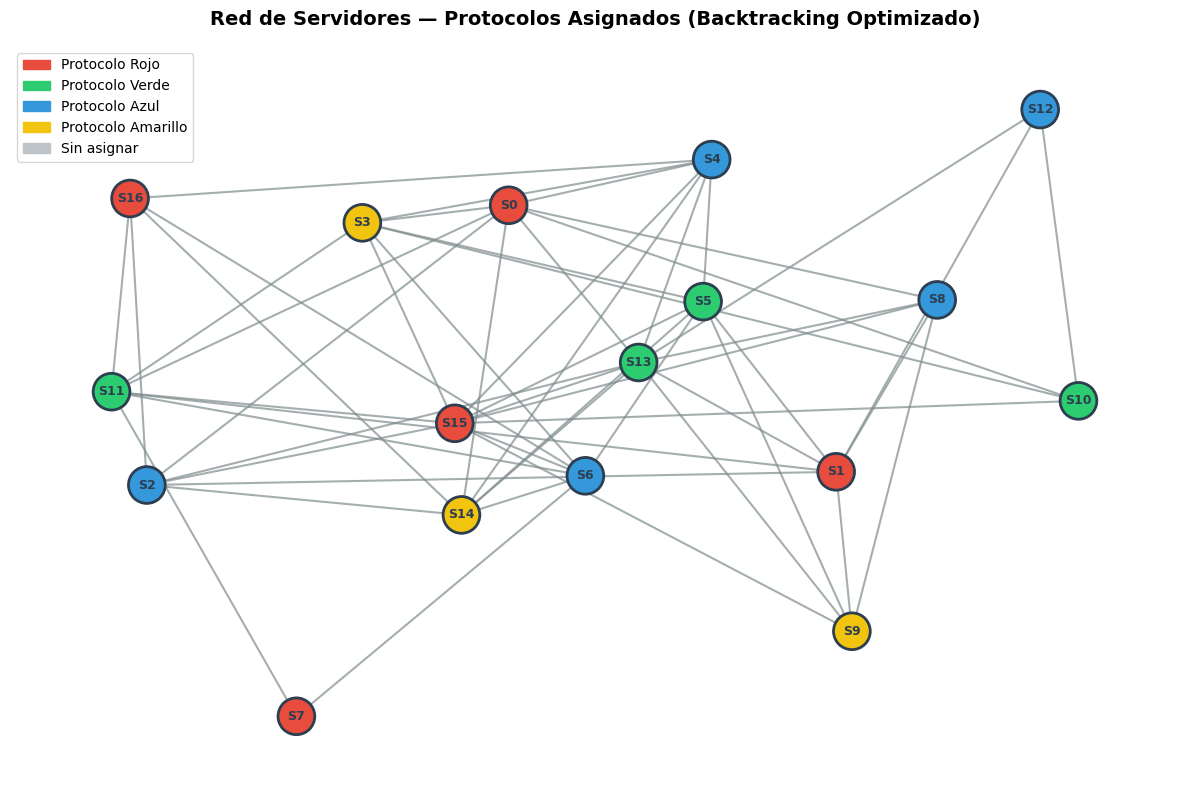

In [10]:
plot_network(
    G,
    assignment=results_opt["solution"],
    title="Red de Servidores — Protocolos Asignados (Backtracking Optimizado)"
)

---
## 9. Análisis de Rendimiento

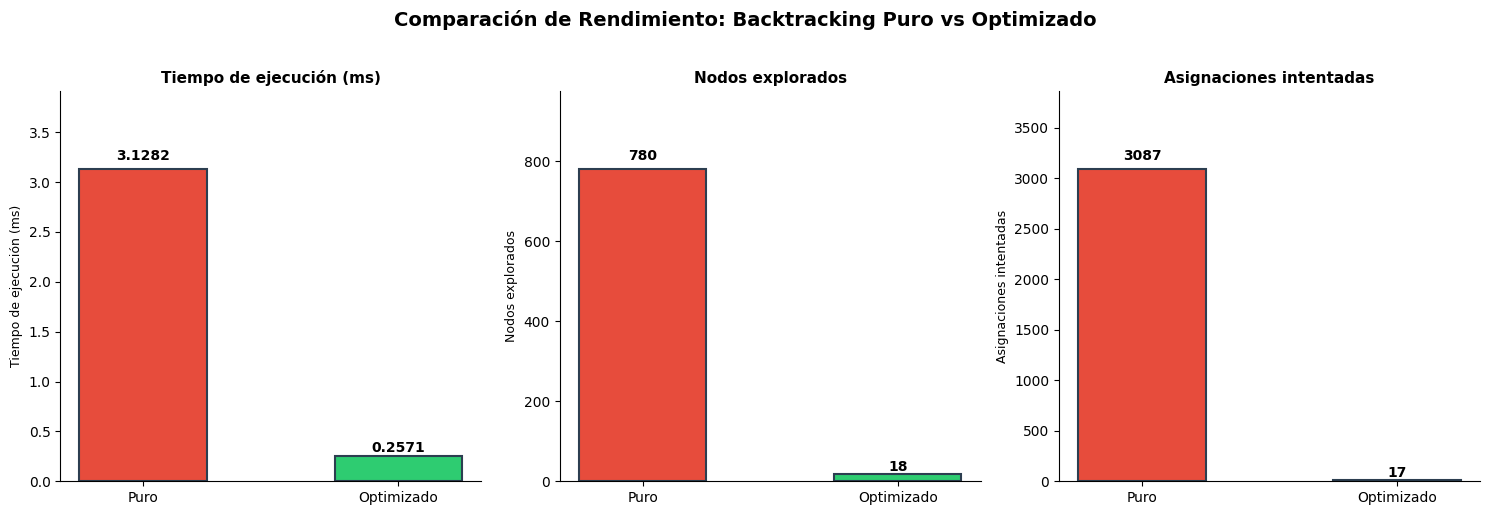


Tabla de Reducción (Puro → Optimizado):
Métrica                              Puro   Optimizado    Reducción
------------------------------------------------------------------
Tiempo de ejecución (ms)           3.1282       0.2571        91.8%
Nodos explorados                      780           18        97.7%
Asignaciones intentadas              3087           17        99.4%


In [11]:
def plot_performance_comparison(results_pure: dict, results_opt: dict):
    """
    Genera gráficas comparativas de las tres métricas clave entre
    Backtracking Puro y Optimizado.
    """
    labels   = ["Puro", "Optimizado"]
    colors   = ["#e74c3c", "#2ecc71"]
    metrics  = [
        ("Tiempo de ejecución (ms)",   [results_pure["time_ms"],    results_opt["time_ms"]]),
        ("Nodos explorados",            [results_pure["nodes"],      results_opt["nodes"]]),
        ("Asignaciones intentadas",     [results_pure["assignments"], results_opt["assignments"]]),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Comparación de Rendimiento: Backtracking Puro vs Optimizado",
                 fontsize=14, fontweight="bold", y=1.02)

    for ax, (title, values) in zip(axes, metrics):
        bars = ax.bar(labels, values, color=colors, edgecolor="#2c3e50",
                      linewidth=1.5, width=0.5)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_ylabel(title, fontsize=9)

        # Etiquetas en las barras
        for bar, val in zip(bars, values):
            label = f"{val:.4f}" if isinstance(val, float) else str(val)
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                    label, ha="center", va="bottom", fontsize=10, fontweight="bold")

        ax.set_ylim(0, max(values) * 1.25)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Tabla de reducción
    print("\nTabla de Reducción (Puro → Optimizado):")
    print(f"{'Métrica':<28} {'Puro':>12} {'Optimizado':>12} {'Reducción':>12}")
    print("-" * 66)
    for title, values in metrics:
        puro, opt = values
        if puro > 0:
            reduction = (1 - opt / puro) * 100
            puro_str  = f"{puro:.4f}" if isinstance(puro, float) else str(puro)
            opt_str   = f"{opt:.4f}"  if isinstance(opt,  float) else str(opt)
            print(f"{title:<28} {puro_str:>12} {opt_str:>12} {reduction:>11.1f}%")
        else:
            print(f"{title:<28} {'0':>12} {'0':>12} {'N/A':>12}")


plot_performance_comparison(results_pure, results_opt)

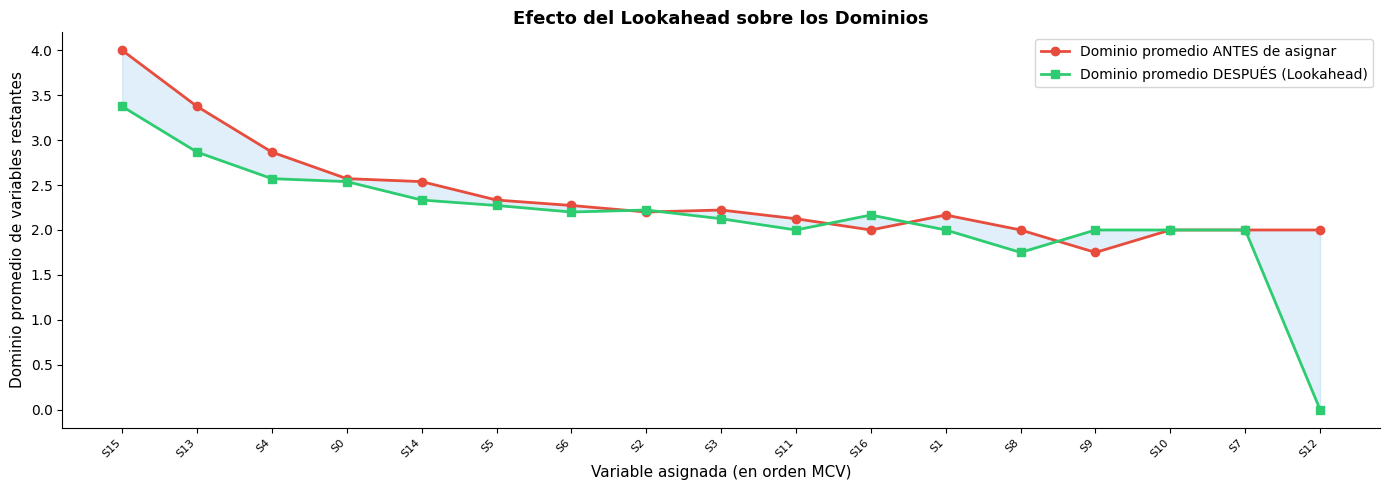

In [12]:
def plot_domain_evolution(csp: NetworkSecurityCSP, solution: dict):
    """
    Visualiza cuántos valores quedan en el dominio de cada variable
    tras el Lookahead aplicando la solución encontrada.
    """
    # Simular el dominio residual con Forward Checking en el orden de la solución
    solver_sim = BacktrackingOptimized(csp)
    domains    = {v: list(vals) for v, vals in csp.domains.items()}
    assignment = {}

    domain_sizes = []  # (paso, variable asignada, tamaños de dominio de no asignados)

    # Reproducir el orden MCV sobre la solución
    order = list(solution.keys())

    for xi in order:
        value = solution[xi]
        before_avg = np.mean([len(domains[v]) for v in csp.variables if v not in assignment])
        domains, _ = solver_sim._forward_check(xi, value, assignment, domains)
        assignment[xi] = value
        after_avg  = np.mean([len(domains[v]) for v in csp.variables if v not in assignment]) \
                     if len(assignment) < len(csp.variables) else 0
        domain_sizes.append((xi, before_avg, after_avg))

    steps   = list(range(1, len(domain_sizes) + 1))
    before  = [d[1] for d in domain_sizes]
    after   = [d[2] for d in domain_sizes]
    xlabels = [d[0] for d in domain_sizes]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(steps, before, "o-", color="#e74c3c", label="Dominio promedio ANTES de asignar", linewidth=2)
    ax.plot(steps, after,  "s-", color="#2ecc71", label="Dominio promedio DESPUÉS (Lookahead)", linewidth=2)
    ax.fill_between(steps, before, after, alpha=0.15, color="#3498db")
    ax.set_xticks(steps)
    ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Variable asignada (en orden MCV)", fontsize=11)
    ax.set_ylabel("Dominio promedio de variables restantes", fontsize=11)
    ax.set_title("Efecto del Lookahead sobre los Dominios", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


plot_domain_evolution(csp, results_opt["solution"])

---
## 10. Análisis Escalado — Múltiples Grafos

Para evaluar el impacto de las heurísticas de forma más robusta, comparamos ambos algoritmos sobre grafos de distintos tamaños.

In [13]:
def benchmark(node_counts: list, edge_prob: float = 0.35, trials: int = 3) -> list:
    """
    Ejecuta ambos solvers sobre grafos de distinto tamaño.
    Promedia los resultados sobre 'trials' semillas distintas.
    """
    results = []

    for n in node_counts:
        pure_nodes_list, opt_nodes_list = [], []
        pure_time_list,  opt_time_list  = [], []

        for seed in range(trials):
            try:
                g   = generate_network(n, edge_prob, seed=seed * 100 + n)
                c   = NetworkSecurityCSP(g, PROTOCOLS)

                sp  = BacktrackingPure(c)
                t0  = time.perf_counter()
                sp.solve()
                pure_time_list.append((time.perf_counter() - t0) * 1000)
                pure_nodes_list.append(sp.calls)

                so  = BacktrackingOptimized(c)
                t0  = time.perf_counter()
                so.solve()
                opt_time_list.append((time.perf_counter() - t0) * 1000)
                opt_nodes_list.append(so.calls)
            except Exception:
                pass

        if pure_nodes_list:
            results.append({
                "n":          n,
                "pure_nodes": np.mean(pure_nodes_list),
                "opt_nodes":  np.mean(opt_nodes_list),
                "pure_ms":    np.mean(pure_time_list),
                "opt_ms":     np.mean(opt_time_list),
            })
        print(f"  n={n:3d} | Puro nodos: {np.mean(pure_nodes_list):8.1f} "
              f"| Opt nodos: {np.mean(opt_nodes_list):8.1f} "
              f"| Speedup: {np.mean(pure_nodes_list)/max(np.mean(opt_nodes_list),1):.2f}x")

    return results


print("Benchmark en progreso...")
bench_results = benchmark(node_counts=[5, 8, 10, 12, 15, 17, 20], trials=3)

Benchmark en progreso...
  n=  5 | Puro nodos:      6.0 | Opt nodos:      6.0 | Speedup: 1.00x
  n=  8 | Puro nodos:      9.0 | Opt nodos:      9.0 | Speedup: 1.00x
  n= 10 | Puro nodos:     11.0 | Opt nodos:     11.0 | Speedup: 1.00x
  n= 12 | Puro nodos:     13.0 | Opt nodos:     13.0 | Speedup: 1.00x
  n= 15 | Puro nodos:     19.7 | Opt nodos:     16.0 | Speedup: 1.23x
  n= 17 | Puro nodos:   1306.3 | Opt nodos:     18.0 | Speedup: 72.57x
  n= 20 | Puro nodos:  54417.0 | Opt nodos:    217.0 | Speedup: 250.77x


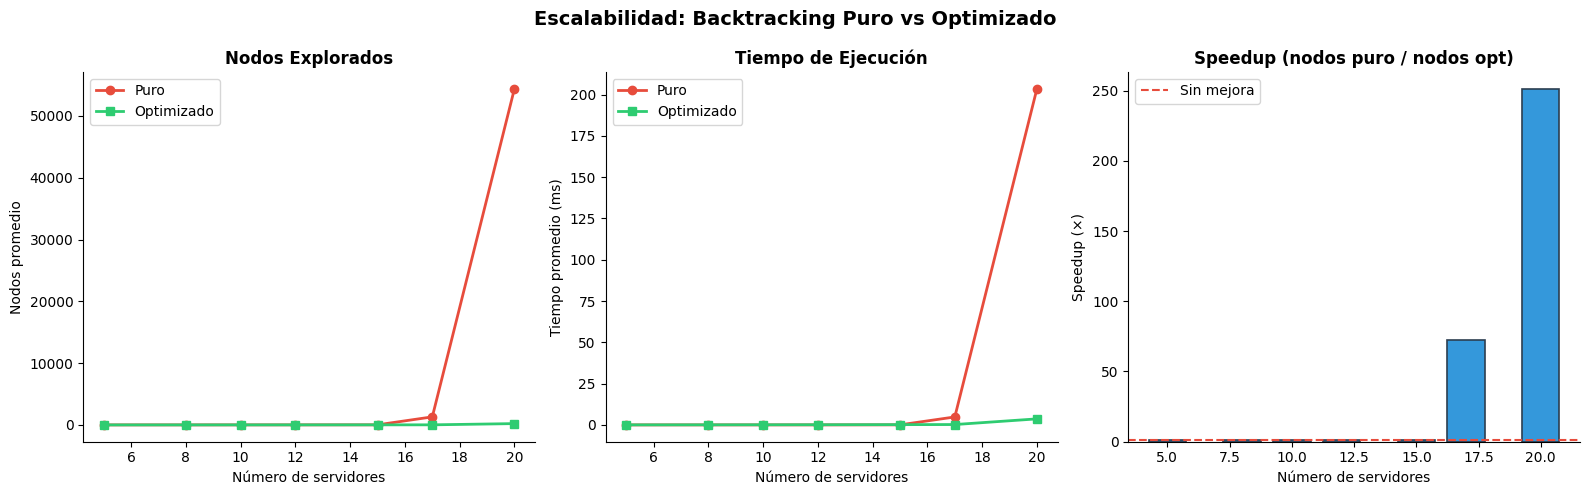

In [14]:
def plot_benchmark(bench_results: list):
    ns         = [r["n"] for r in bench_results]
    pure_nodes = [r["pure_nodes"] for r in bench_results]
    opt_nodes  = [r["opt_nodes"]  for r in bench_results]
    pure_ms    = [r["pure_ms"]    for r in bench_results]
    opt_ms     = [r["opt_ms"]     for r in bench_results]
    speedup    = [p / max(o, 1) for p, o in zip(pure_nodes, opt_nodes)]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Escalabilidad: Backtracking Puro vs Optimizado",
                 fontsize=14, fontweight="bold")

    # Nodos explorados
    ax = axes[0]
    ax.plot(ns, pure_nodes, "o-", color="#e74c3c", label="Puro",       linewidth=2)
    ax.plot(ns, opt_nodes,  "s-", color="#2ecc71", label="Optimizado", linewidth=2)
    ax.set_title("Nodos Explorados", fontweight="bold")
    ax.set_xlabel("Número de servidores")
    ax.set_ylabel("Nodos promedio")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    # Tiempo
    ax = axes[1]
    ax.plot(ns, pure_ms, "o-", color="#e74c3c", label="Puro",       linewidth=2)
    ax.plot(ns, opt_ms,  "s-", color="#2ecc71", label="Optimizado", linewidth=2)
    ax.set_title("Tiempo de Ejecución", fontweight="bold")
    ax.set_xlabel("Número de servidores")
    ax.set_ylabel("Tiempo promedio (ms)")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    # Speedup
    ax = axes[2]
    ax.bar(ns, speedup, color="#3498db", edgecolor="#2c3e50", linewidth=1.2, width=1.5)
    ax.axhline(1, color="#e74c3c", linestyle="--", linewidth=1.5, label="Sin mejora")
    ax.set_title("Speedup (nodos puro / nodos opt)", fontweight="bold")
    ax.set_xlabel("Número de servidores")
    ax.set_ylabel("Speedup (×)")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


plot_benchmark(bench_results)

---
## 11. Conclusiones

### Modelado CSP

El problema de asignación de protocolos se mapea naturalmente a un CSP:
- **Variables**: cada servidor es una variable.
- **Dominio**: los 4 protocolos disponibles.
- **Factores**: restricciones binarias $f_{ij} = [X_i \neq X_j]$ por cada enlace.
- **Objetivo**: $\arg\max_x \prod_{(i,j) \in E} f_{ij}(x_i, x_j)$, equivalente a encontrar una asignación con $\text{Weight}(x) = 1$.

### Impacto de las Heurísticas

| Heurística | Qué hace | Beneficio |
|---|---|---|
| **MCV/MRV** | Elige la variable con menor dominio restante | Detecta fallos temprano, poda más agresiva |
| **Lookahead** | Elimina valores inconsistentes de vecinos tras asignar | Reduce dominios antes de explorar, evita callejones sin salida |
| **LCV** | Ordena valores dejando más opciones a vecinos | Aumenta probabilidad de encontrar solución sin backtrack |

### Análisis del Benchmark por Escala

Los resultados del benchmark revelan un patrón importante que vale la pena explicar:

| n (servidores) | Speedup | Interpretación |
|---|---|---|
| 5 – 12 | **1.00×** | Ambos algoritmos se comportan igual |
| 15 | 1.23× | Comienza a haber diferencia |
| 17 | 72.57× | Diferencia significativa |
| 20 | 250.77× | Diferencia drástica |

**¿Por qué el speedup es 1.00× en grafos pequeños (n ≤ 12)?**

En grafos con pocos nodos y probabilidad de arista $p = 0.35$, la densidad de conexiones es lo suficientemente baja como para que el dominio de 4 colores sea holgado respecto al número de restricciones activas. En esas condiciones, el backtracking puro encuentra una solución válida en el primer intento — sin necesidad de retroceder — de forma idéntica al optimizado. Ambos recorren exactamente $n+1$ nodos en el árbol de búsqueda (uno por variable más el nodo raíz).

El MCV y el Lookahead solo muestran su ventaja cuando el problema se vuelve **suficientemente restrictivo**: a medida que $n$ crece, la conectividad del grafo aumenta en promedio y el backtracking puro empieza a explorar ramas que el optimizado podría haber descartado de inmediato. Esto es consistente con la teoría: las heurísticas son útiles precisamente en la región donde el espacio de búsqueda es grande y las restricciones están fuertemente acopladas.

**Punto de quiebre observado**: entre $n = 15$ y $n = 17$ el grafo pasa de un régimen "fácil" a uno donde el backtracking puro empieza a fallar en múltiples ramas. Esto explica el salto de 1.23× a 72.57× en speedup.

### Conexión con Ciberseguridad

La restricción $X_i \neq X_j$ modela directamente la defensa contra **movimiento lateral**:
si un atacante compromete un servidor con Protocolo A, los servidores vecinos con protocolos
distintos presentan una superficie de ataque diferente, dificultando la propagación automática.

### Casos Especiales del Framework

Como vimos en clase, el framework de Factor Graphs unifica:
- **CSP** (este problema): factores binarios $\{0, 1\}$
- **SAT**: variables booleanas, factores cláusulas lógicas
- **LP / ILP / MIP**: variables reales/enteras, factores desigualdades lineales

Todos comparten el mismo objetivo: $\arg\max_x \text{Weight}(x)$.